# USTAWIENIA

In [1]:
INPUT_PATH="WUM-watroba-histopat_SH/H19-100200 HE.ndpi"
TARGET_MPP=1
DOWNSAMPLE_BASE=2
PATCH_OVERLAP=0.2
PATCH_SIZE=640
OUT_DIR_BASE="out"

# Importy

In [2]:
from openslide import OpenSlide
import openslide
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np


# Wczytanie danych

Wczytano obraz o wymiarach 184320x52992. Ilość poziomów obrazu to 9
0.22624946265752618x0.22631602770108178


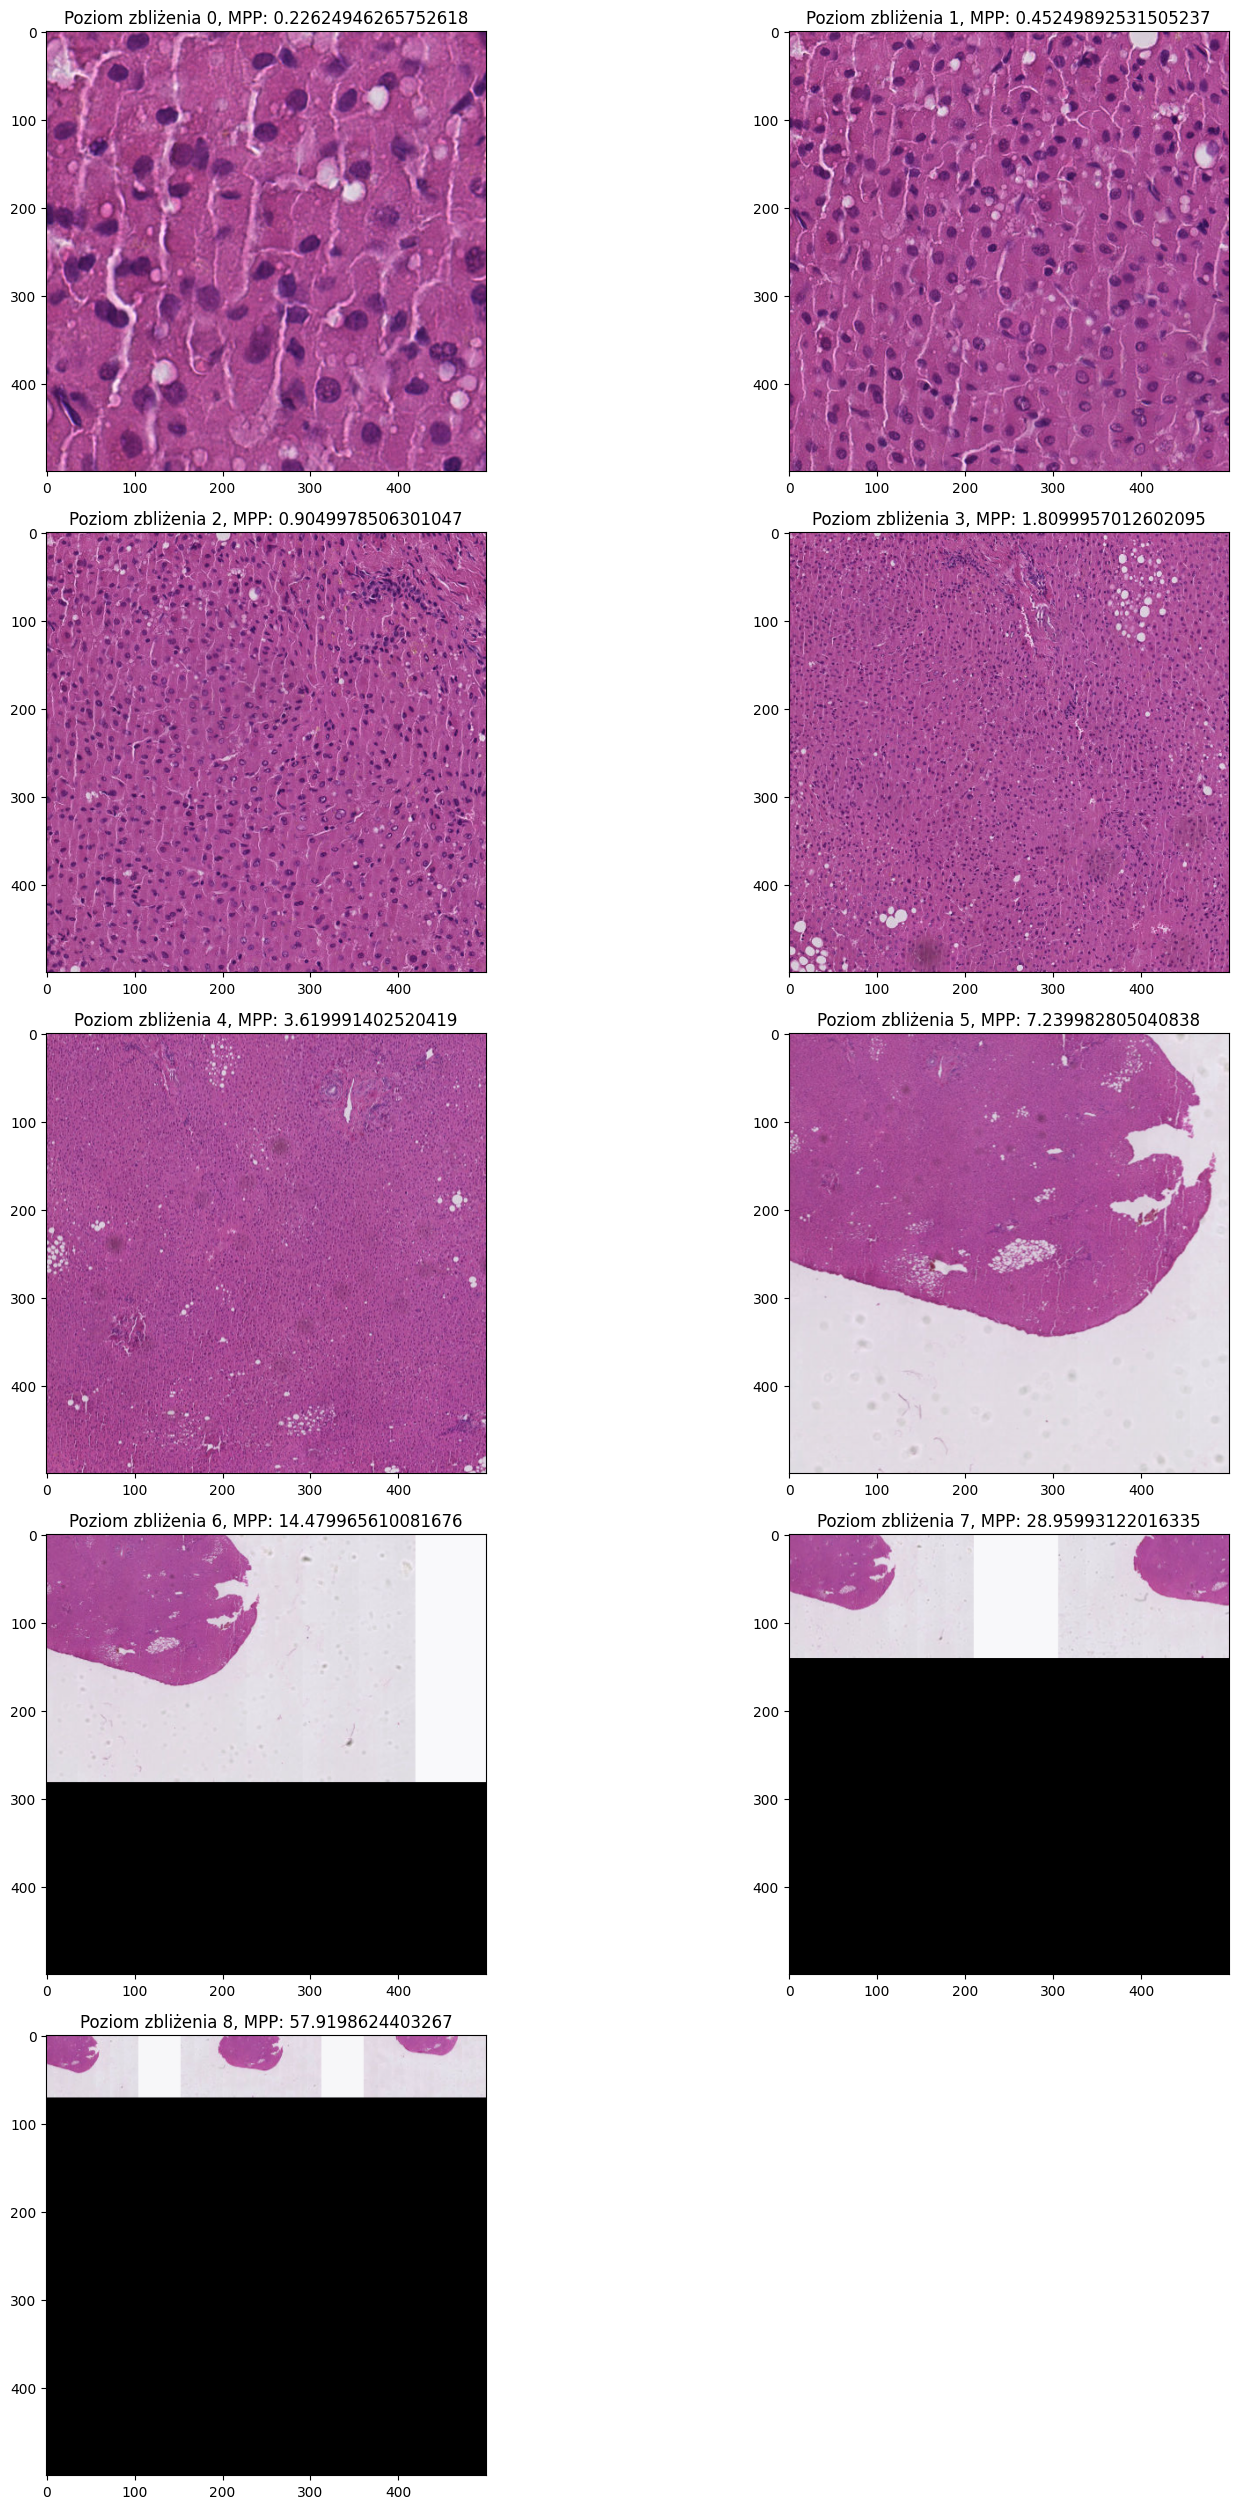

In [3]:
slide = OpenSlide(Path(INPUT_PATH))
[width, height] = slide.dimensions
print(f"Wczytano obraz o wymiarach {width}x{height}. Ilość poziomów obrazu to {slide.level_count}")

# Możliwe, że konieczne będzie przeskalowanie obrazu
# Możliwe róœnież, że drobna różnica wynika z niedokładności
mpp_x0 = float(slide.properties[openslide.PROPERTY_NAME_MPP_X])
mpp_y0 = float(slide.properties[openslide.PROPERTY_NAME_MPP_Y])
print(f"{mpp_x0}x{mpp_y0}")

downsamples = slide.level_downsamples

plt.figure(figsize=(15, 5 * slide.level_count))
for i in range(slide.level_count):
    ax = plt.subplot(slide.level_count,2, i+1)
    mpp = mpp_x0 * downsamples[i]

    if not downsamples[i]  == pow(DOWNSAMPLE_BASE, i) * downsamples[0]:
        raise ValueError("Zapisane w pliku downsample nie zgadzają się z podstawą")

    ax.set_title(f"Poziom zbliżenia {i}, MPP: {mpp}")
    
    ax.imshow(slide.read_region((10000,35000), i, (500,500)).convert("RGB"))

plt.tight_layout()

## Generacja bounding boxów

In [4]:
from collections import namedtuple
from enum import Enum
from typing import Dict, List
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon
from scipy.spatial import KDTree

proj_id = Path(INPUT_PATH).stem
proj_dir = Path(OUT_DIR_BASE).joinpath(proj_id)
Point = namedtuple("Point", ["x", "y"])
# KDTree jest używane do znajdowania punktów w regionie


class AnnotGroups(Enum):
    STEATOSIS = 1, "Steatosis"
    NOT_STEATOSIS = 2, "Not steatosis"

    @classmethod
    def from_label(cls, label):
        for member in cls:
            if member.value[1] == label:
                return member
        raise ValueError(f"No status found for label: {label}")
  
class Spline:
    def __init__(self) -> None:
        self.points : List[Point] = []
        self.group : AnnotGroups

    def copy(self) -> Spline:
        ret = Spline()
        ret.group = self.group
        ret.points = []
        for point in self.points:
            ret.points.append(Point(x=point.x, y = point.y))

        return ret


    def __hash__(self) -> int:
        values = [self.group.value[0]]
 
        for point in self.points:
            values.append(point.x)
            values.append(point.y)

        return tuple(values).__hash__()
            

    def __eq__(self, value: object) -> bool:
        if not isinstance(value, Spline): return False
        elif self.group != value.group: return False
        elif len(self.points) != len(value.points): return False

        l = len(self.points)
        for i in range(l):
            a = self.points[i]
            b = value.points[i]

            if a[0] != b[0]: return False
            elif a[1] != b[1]: return False

        return True




point_parent_spline : Dict[Point, List[Spline]] = dict()


with open(Path(INPUT_PATH).parent.joinpath(f"{Path(INPUT_PATH).stem}.xml"), "r") as file:
    root = ET.parse(file).getroot()
    annots = root.findall("Annotations/Annotation")
    for annot in annots:
        group = annot.get("Name")
        if group not in ["Steatosis", "Not steatosis"]:
            continue
        xml_coords = annot.findall("Coordinates/Coordinate")
        xml_coords.sort(key=lambda e : int(e.get("order", -1)))

        spline = Spline()
        spline.group = AnnotGroups.from_label(group)
        for c in xml_coords:
            x = float(c.get("X", -1))
            y = float(c.get("Y", -1))
            if x == -1 or y == -1: raise ValueError("Brak koordynata dla danego punktu")
            p = Point(x, y)
            spline.points.append(p)
            
            l = point_parent_spline.get(p, []) 
            
            l.append(spline)
            point_parent_spline[p] = l
# Konieczna będzie zamiana typu z point na listę
kdtree_points_mapped : List[List[float]] = list(map(lambda a: [a.x, a.y], point_parent_spline.keys()))
print(kdtree_points_mapped)

kdtree = KDTree(data=kdtree_points_mapped)

class BoundingBox:
    group: AnnotGroups
    centerx: float
    centery: float
    width: float
    height: float

def get_bboxes_for_region(start : tuple[int, int], size: float) -> List[BoundingBox]:
    end = [
        start[0] + size,
        start[1] + size
    ]
    center = [
        float(start[0] + end[0])/2,
        float(start[1] + end[1])/2
    ]

    indices : List[int] = kdtree.query_ball_point(center, size/2, p=np.inf)
    print(f"center: {center}, size: {size}")
    bboxes : List[BoundingBox] = []
    # Teraz dla każdego splina który dotyka tego punktu ograniczam bounding boxy do rozmiaru regionu
    done_splines = set()
    for index in indices:
        point_inside_coords : List[float] = kdtree_points_mapped[index]
        if len(point_inside_coords) != 2 or point_inside_coords[0] is None or point_inside_coords[1] is None: raise RuntimeError()
        point_inside = Point(x=point_inside_coords[0], y=point_inside_coords[1])
        splines = point_parent_spline.get(point_inside)
        
        if splines is None: 
            raise RuntimeError(f"{center} : {point_inside} has no parent Spline")        # Każdy punkt powinien mieć przypisanego splina
        for spline in splines:
            # Jeżeli dany spline będzie miał kilka punktów w danym regionie zostanie zwrócony kilka razy, dlatego należy sprawdzać, czy już został on zrobiony
            if spline in done_splines:
                continue
            done_splines.add(spline)

            spline_points : List[Point] = []

            for point in spline.points:
                
                spline_points.append(Point(
                    x=(max(min(point.x, start[0]), end[0]) - start[0])/size,
                    y=(max(min(point.y, start[1]), end[1]) - start[1])/size
                ))

            bbox = BoundingBox()
            bbox_points = Polygon(spline_points).bounds
            bbox.centerx = (bbox_points[0] + bbox_points[2])/2
            bbox.centery = (bbox_points[1] + bbox_points[3])/2
            bbox.width = (bbox_points[2] - bbox_points[0])
            bbox.height = (bbox_points[3] - bbox_points[1])
            bbox.group = spline.group

            bboxes.append(bbox)
            

        

        
    return bboxes


    
        



[[72157.0938, 42184.9414], [71989.1406, 42253.8398], [71933.1641, 42417.4844], [71756.6016, 42430.4023], [71692.0078, 42598.3477], [71808.2734, 42727.5391], [71679.0859, 42843.8125], [71532.6719, 42942.8555], [71420.7031, 43080.6602], [71528.3672, 43218.4609], [71679.0859, 43304.5898], [71851.3438, 43356.2656], [72023.5938, 43339.0391], [72178.625, 43252.9141], [72342.2656, 43196.9297], [72492.9844, 43110.8047], [72635.0938, 43007.4531], [72803.0391, 42964.3867], [72958.0703, 42873.957], [73108.7891, 42783.5234], [73255.2109, 42684.4766], [73410.2344, 42606.9609], [73565.2656, 42529.4492], [73556.6484, 42357.1953], [73703.0703, 42262.4531], [73853.7891, 42172.0195], [73728.9062, 42051.4453], [73556.6484, 41995.4609], [73393.0078, 41926.5586], [73229.3672, 41870.5781], [73057.1172, 41917.9453], [72902.0859, 41995.4609], [72738.4453, 42051.4453], [72566.1953, 42008.3789], [72393.9375, 41978.2344], [72230.2969, 42047.1367], [72299.2031, 42150.4883], [69197.5, 43720.2031], [69175.6484, 436

## Skalowanie

In [5]:
import math
from time import sleep
from typing import Tuple
from matplotlib import patches
from matplotlib.axes import Axes
from numpy.typing import NDArray
from PIL import Image


def read_region(mpp : float, pos: Tuple[int, int], size: Tuple[int, int]):
    level = math.log(mpp/mpp_x0, DOWNSAMPLE_BASE)
    if(level % 1 == 0): return slide.read_region(pos, int(level), size)
    elif(level < 0 or level > slide.level_count - 1): raise ValueError("Wybrany poziom nie jest obsługiwany") 
    prev_level = int(level)

    scale_up = pow(DOWNSAMPLE_BASE, level - prev_level)

    frag_img = slide.read_region(pos, prev_level, (int(size[0] * scale_up), int(size[1] * scale_up)))
    return frag_img.resize(size, resample=Image.Resampling.LANCZOS)

In [6]:
ix = kdtree.query_ball_point((71000,37573), 5000, p=np.inf)
for i in ix:
    print(kdtree_points_mapped[i])

[75995.2344, 34385.3203]
[75957.2812, 34389.9492]
[66104.4609, 36008.3164]
[66107.0156, 36043.2617]
[66119.8047, 35976.7773]
[66128.3281, 36071.3906]
[66253.625, 35954.6133]
[66133.4375, 35928.1914]
[66228.0547, 35891.5391]
[66182.8828, 35904.3242]
[66236.5781, 35924.7812]
[66167.5391, 35918.8125]
[66196.5156, 35935.8633]
[66136.8516, 35957.9297]
[66159.8672, 35967.3984]
[66187.9922, 35987.8555]
[66196.5156, 36021.1016]
[66188.8438, 36054.3438]
[66161.5703, 35986.1523]
[66192.2578, 35969.957]
[66162.4219, 36077.3594]
[66309.0312, 35929.043]
[66457.3516, 35912.8477]
[66310.7344, 35894.9453]
[66257.8906, 35874.4883]
[66291.9844, 35883.8672]
[66431.7734, 35920.5195]
[66418.9922, 35953.7617]
[66288.5781, 35957.1719]
[66429.2188, 35982.7422]
[66441.1562, 35980.1875]
[66447.1172, 35990.4141]
[66441.1562, 36102.0781]
[66418.1406, 36009.168]
[66417.2891, 36077.3594]
[66411.3203, 36043.2617]
[66463.3125, 35984.4492]
[66463.3125, 35905.1758]
[66506.7891, 35977.6289]
[66494.0, 36000.6445]
[66495.

# Dzielenie na patche

In [7]:
import shutil

patch_dim = [
    PATCH_SIZE*(1-PATCH_OVERLAP) * TARGET_MPP / mpp_x0,
    PATCH_SIZE*(1-PATCH_OVERLAP) * TARGET_MPP / mpp_y0
]


patches_hcount = math.ceil(slide.dimensions[0]/patch_dim[0])
patches_vcount = math.ceil(slide.dimensions[1]/patch_dim[1])
patch_count = patches_hcount * patches_vcount
print(f"Zostanie utworzonych {patch_count} patchy")

img_dir = proj_dir.joinpath("images")

if img_dir.is_dir():
    shutil.rmtree(img_dir)
os.makedirs(img_dir)
mpp_scale_up = [
    TARGET_MPP / mpp_x0,
    TARGET_MPP / mpp_y0
]

for col in range(patches_hcount):
    x_pos = int(col * patch_dim[0] )
    for row in range(patches_vcount):
        y_pos = int(row * patch_dim[1])
        im = read_region(TARGET_MPP, (x_pos, y_pos), (PATCH_SIZE, PATCH_SIZE))
        write_path = img_dir.joinpath(f"{x_pos}_{y_pos}.png")
        
        with open(write_path, "wb"):
            im.save(write_path)
            


Zostanie utworzonych 1968 patchy
